# 02.7 — Eigenvalues & Eigenvectors

**Phase:** 02 — Mathematics for ML

**Difficulty:** Intermediate

**Priority:** Core — PCA, SVD, and spectral methods depend on this

**Status:** VERIFIED

---

## 1. What Are We Solving?

When you multiply a matrix by a vector, most vectors get rotated *and* stretched. But some special vectors only get **stretched** — their direction stays the same. These are **eigenvectors**, and the stretching factor is the **eigenvalue**.

This isn't just abstract math. Eigenvectors and eigenvalues are the foundation of:
- **PCA**: finding the directions of maximum variance in your data
- **SVD**: decomposing matrices for recommendations and compression
- **Spectral clustering**: finding communities in graphs
- **PageRank**: ranking web pages by importance

## 2. Why Does This Matter?

PCA — one of the most widely used dimensionality-reduction techniques — is literally an eigenvalue problem on the covariance matrix. When you reduce 100 features to 10, you're finding the 10 eigenvectors with the largest eigenvalues.

Eigenvalues also tell you:
- How much variance each principal component captures
- Whether a matrix is singular (eigenvalue = 0)
- Whether a Markov chain converges (largest eigenvalue)
- How stable a dynamical system is (eigenvalues < 1)

## 3. Prerequisites

- Unit 02.1 (Vectors & Matrices)
- Unit 02.2 (Matrix Operations) — you should understand matrix-vector multiplication

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- [ ] Define eigenvalues and eigenvectors and explain their geometric meaning
- [ ] Compute eigenvalues and eigenvectors with NumPy
- [ ] Understand eigendecomposition and when it's possible
- [ ] Apply PCA for dimensionality reduction
- [ ] Interpret eigenvalues as variance captured by each component

## 5. Mental Model

Imagine stretching a rubber sheet with a matrix transformation. Most points move in complicated ways. But some lines through the origin stay on themselves — they just get stretched or compressed.

```
A × v = λ × v
↑      ↑
matrix  eigenvalue (scalar)
times
eigenvector

The eigenvector v stays on the same line.
The eigenvalue λ says how much it stretched.
```

**PCA insight:** The eigenvector of the covariance matrix with the largest eigenvalue is the direction of maximum variance in your data. The second-largest is the next direction of maximum variance (orthogonal to the first), and so on.

## 6. Core Concepts: Definition and Intuition

For a square matrix `A`, a non-zero vector `v` is an **eigenvector** with **eigenvalue** `λ` if:

```
A × v = λ × v

Geometric meaning:
  - A rotates and stretches most vectors
  - Eigenvectors are special: they stay on the same line (just stretched)
  - Eigenvalue λ says how much: λ > 1 = stretched, 0 < λ < 1 = compressed, λ < 0 = flipped
```

**How to find them:**
```
A × v = λ × v
A × v - λ × v = 0
(A - λI) × v = 0

For non-trivial v: det(A - λI) = 0  ← characteristic equation
Solve for λ, then find v for each λ.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example matrix
A = np.array([[2.0, 0.0],
              [0.0, 3.0]])

# This is a diagonal matrix. Its eigenvectors are the standard basis vectors.
# e1 = [1, 0] with eigenvalue 2
# e2 = [0, 1] with eigenvalue 3
v1 = np.array([1.0, 0.0])
v2 = np.array([0.0, 1.0])

print("A * v1 =", A @ v1, "= 2 * v1 =", 2 * v1)
print("A * v2 =", A @ v2, "= 3 * v2 =", 3 * v2)
print("\nThe matrix stretches v1 by 2x and v2 by 3x, without rotating them.")


A * v1 = [2. 0.] = 2 * v1 = [2. 0.]
A * v2 = [0. 3.] = 3 * v2 = [0. 3.]

The matrix stretches v1 by 2x and v2 by 3x, without rotating them.


## 7. Computing Eigenvalues with NumPy

NumPy's `np.linalg.eig` computes eigenvalues and eigenvectors. Let's use a non-diagonal matrix to see the general case.


In [2]:
# Compute eigenvalues and eigenvectors with NumPy
A = np.array([[4.0, 1.0],
              [2.0, 3.0]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors (columns):")
print(eigenvectors)

# Verify: A * v = lambda * v for each eigenvector
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    lhs = A @ v
    rhs = lam * v
    print(f"\nEigenvector {i}: A*v = {lhs}, lambda*v = {rhs}")
    print(f"Match: {np.allclose(lhs, rhs)}")


Eigenvalues: [5.+0.j 2.+0.j]
Eigenvectors (columns):
[[ 0.70710678+0.j -0.4472136 +0.j]
 [ 0.70710678+0.j  0.89442719+0.j]]

Eigenvector 0: A*v = [3.53553391+0.j 3.53553391+0.j], lambda*v = [3.53553391+0.j 3.53553391+0.j]
Match: True

Eigenvector 1: A*v = [-0.89442719+0.j  1.78885438+0.j], lambda*v = [-0.89442719+0.j  1.78885438+0.j]
Match: True


## 8. Eigendecomposition

A diagonalizable matrix can be decomposed as:

`A = V * Lambda * V^-1`

where `V` has the eigenvectors as columns and `Lambda` is a diagonal matrix of eigenvalues. This is the **eigendecomposition**.

For a **symmetric** matrix (like a covariance matrix), the eigenvectors are orthonormal and `V^-1 = V^T`, giving `A = V * Lambda * V^T`.


In [3]:
# Eigendecomposition: A = V * Lambda * V^-1
A = np.array([[4.0, 1.0],
              [2.0, 3.0]])

eigenvalues, eigenvectors = np.linalg.eig(A)
Lambda = np.diag(eigenvalues)
V = eigenvectors

# Reconstruct A
A_reconstructed = V @ Lambda @ np.linalg.inv(V)

print("Original A:")
print(A)
print("\nReconstructed A = V * Lambda * V^-1:")
print(A_reconstructed)
print(f"\nReconstruction matches: {np.allclose(A, A_reconstructed)}")

# For symmetric matrices, V is orthonormal: V^T = V^-1
S = np.array([[3.0, 1.0],
              [1.0, 2.0]])  # symmetric
evals, evecs = np.linalg.eig(S)
print("\nSymmetric matrix: V^T * V = I (orthonormal):",
      np.allclose(evecs.T @ evecs, np.eye(2)))


Original A:
[[4. 1.]
 [2. 3.]]

Reconstructed A = V * Lambda * V^-1:
[[4.+0.j 1.+0.j]
 [2.+0.j 3.+0.j]]

Reconstruction matches: True

Symmetric matrix: V^T * V = I (orthonormal): True


## 9. Eigenvalues and Variance

For a **covariance matrix**, the eigenvalues represent the **variance** along each principal direction, and the eigenvectors are the **principal components** (directions of maximum variance).

This is the foundation of **PCA**: project the data onto the eigenvectors with the largest eigenvalues to keep the most variance while reducing dimensions.


In [4]:
# Eigenvalues of a covariance matrix = variance along principal directions
np.random.seed(42)

# Generate correlated 2D data
n = 500
x = np.random.randn(n)
y = 0.8 * x + 0.6 * np.random.randn(n)  # correlated with x
data = np.vstack([x, y]).T

# Covariance matrix
cov = np.cov(data.T)
print("Covariance matrix:")
print(cov)

# Eigenvalues and eigenvectors of the covariance matrix
# Use eigh: covariance is symmetric, so eigenvalues are real
eigenvalues, eigenvectors = np.linalg.eigh(cov)
# eigh returns ascending order; reverse to descending
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
print("\nEigenvalues (variance along each principal direction):", eigenvalues)
print("Total variance:", np.sum(eigenvalues))
print("\nFirst principal component (direction of max variance):", eigenvectors[:, 0])

# Fraction of variance explained by each component
explained = eigenvalues / np.sum(eigenvalues)
print("\nFraction of variance explained:", explained)
print(f"First component explains {explained[0]:.1%} of variance")


Covariance matrix:
[[0.96285794 0.7267153 ]
 [0.7267153  0.89084767]]

Eigenvalues (variance along each principal direction): [1.65445949 0.19924611]
Total variance: 1.8537056033316937

First principal component (direction of max variance): [-0.72439089 -0.68938946]

Fraction of variance explained: [0.8925147 0.1074853]
First component explains 89.3% of variance


## 10. Visualizing Principal Components

Let's visualize the data and its principal components (eigenvectors of the covariance matrix).


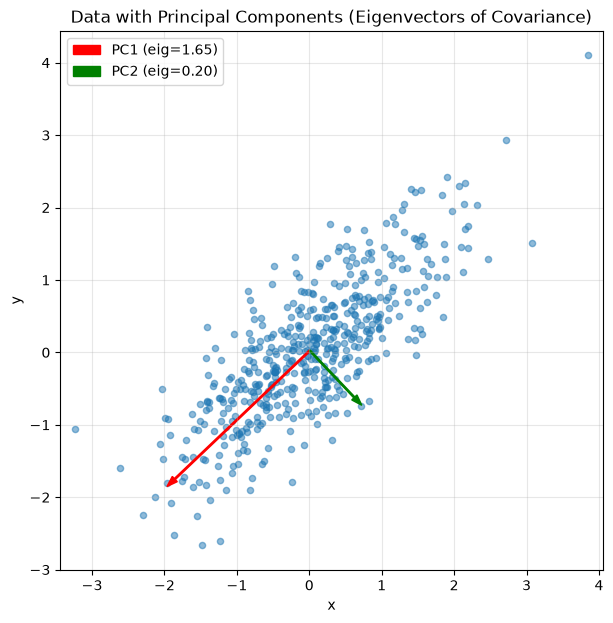

The red arrow (PC1) points in the direction of greatest variance.


In [5]:
# Visualize data and principal components
plt.figure(figsize=(7, 7))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, s=20)

# Draw principal components scaled by their eigenvalues
mean = np.mean(data, axis=0)
for i in range(2):
    vec = eigenvectors[:, i]
    scale = np.sqrt(eigenvalues[i]) * 2
    plt.arrow(mean[0], mean[1], vec[0]*scale, vec[1]*scale,
              color="red" if i == 0 else "green", width=0.02,
              head_width=0.1, label=f"PC{i+1} (eig={eigenvalues[i]:.2f})")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Data with Principal Components (Eigenvectors of Covariance)")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()
print("The red arrow (PC1) points in the direction of greatest variance.")


## 11. PCA for Dimensionality Reduction

PCA reduces dimensions by projecting data onto the top `k` eigenvectors. This keeps the most variance while discarding the least important directions. Let's reduce 2D data to 1D and reconstruct it.


In [6]:
# PCA: reduce 2D to 1D and reconstruct
def pca(data, k):
    # Center the data
    mean = np.mean(data, axis=0)
    centered = data - mean
    # Covariance and eigendecomposition
    cov = np.cov(centered.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Sort by descending eigenvalue
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    eigenvalues = eigenvalues[idx]
    # Project onto top k components
    W = eigenvectors[:, :k]
    projected = centered @ W
    # Reconstruct
    reconstructed = projected @ W.T + mean
    return projected, reconstructed, eigenvalues

projected, reconstructed, eigenvalues = pca(data, 1)

print(f"Original shape: {data.shape}")
print(f"Projected shape (1D): {projected.shape}")
print(f"Variance retained: {eigenvalues[0] / np.sum(eigenvalues):.1%}")

# Reconstruction error
error = np.mean((data - reconstructed) ** 2)
print(f"Mean squared reconstruction error: {error:.4f}")


Original shape: (500, 2)
Projected shape (1D): (500, 1)
Variance retained: 89.3%
Mean squared reconstruction error: 0.0994


## 12. Visualizing PCA Reconstruction

Let's see how well 1D PCA reconstructs the original 2D data.


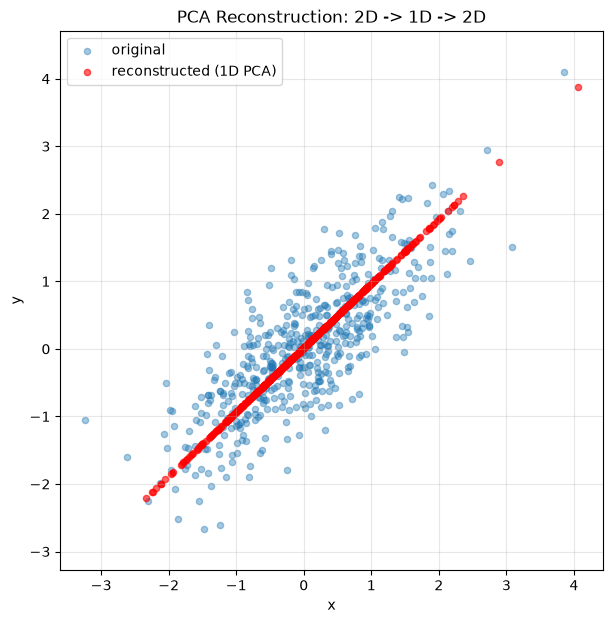

The reconstructed points lie on the line of PC1 - the direction of greatest variance.


In [7]:
# Visualize original vs reconstructed
plt.figure(figsize=(7, 7))
plt.scatter(data[:, 0], data[:, 1], alpha=0.4, s=20, label="original")
plt.scatter(reconstructed[:, 0], reconstructed[:, 1], alpha=0.6, s=20,
            color="red", label="reconstructed (1D PCA)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("PCA Reconstruction: 2D -> 1D -> 2D")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()
print("The reconstructed points lie on the line of PC1 - the direction of greatest variance.")


## 13. Failure Case: Non-Diagonalizable Matrix

Not every matrix is diagonalizable. A **defective** matrix has fewer than `n` independent eigenvectors. Also, a matrix can have **complex** eigenvalues, which complicates interpretation.


In [8]:
# Failure case: complex eigenvalues
# A rotation matrix has complex eigenvalues
R = np.array([[0.0, -1.0],
              [1.0,  0.0]])  # 90-degree rotation

evals, evecs = np.linalg.eig(R)
print("Rotation matrix eigenvalues:", evals)
print("These are complex (i and -i) - a rotation has no real eigenvectors.")
print("\nThis is why we use the covariance matrix (symmetric, real eigenvalues)")
print("for PCA rather than arbitrary matrices.")


Rotation matrix eigenvalues: [0.+1.j 0.-1.j]
These are complex (i and -i) - a rotation has no real eigenvectors.

This is why we use the covariance matrix (symmetric, real eigenvalues)
for PCA rather than arbitrary matrices.


## 14. Debugging: Common Errors

- **Eigenvalues not sorted**: `np.linalg.eig` does not sort eigenvalues. Always sort by descending magnitude before selecting top-k.
- **Using `eig` instead of `eigh`**: for symmetric matrices (like covariance), use `np.linalg.eigh` - it's faster and guarantees real eigenvalues.
- **Forgetting to center data**: PCA requires centered data (subtract the mean) before computing the covariance.
- **Complex eigenvalues**: if you get complex values, the matrix isn't symmetric - check your input.

## 15. Real-World Considerations

- **PCA** is used for dimensionality reduction, visualization, and denoising.
- **Eigenvalues** in Markov chains give the convergence rate; the largest eigenvalue is 1 for a stochastic matrix.
- **SVD** (singular value decomposition) generalizes eigendecomposition to non-square matrices and is more numerically stable - it's what `sklearn.decomposition.PCA` actually uses.
- **Spectral clustering** uses eigenvectors of the graph Laplacian.

## 16. Common Mistakes

- Not sorting eigenvalues before selecting top-k.
- Forgetting to center data before PCA.
- Using `eig` on large symmetric matrices instead of `eigh`.
- Interpreting eigenvectors of a non-symmetric matrix as orthogonal.

## 17. When NOT to Use

- Don't use eigendecomposition for non-square matrices - use SVD instead.
- Don't use PCA when interpretability of original features matters more than variance.
- Don't use PCA on data that should be scaled - always standardize features first.

## 18. Challenge

Use `np.linalg.eigh` to compute the eigenvalues of a covariance matrix, sort them in descending order, and report the fraction of variance explained by the top eigenvalue.


In [9]:
# Challenge: eigenvalues of a covariance matrix, sorted
np.random.seed(123)
X = np.random.randn(300, 3)
X[:, 1] = 0.9 * X[:, 0] + 0.4 * np.random.randn(300)  # correlated
X[:, 2] = 0.1 * np.random.randn(300)  # low variance

cov = np.cov(X.T)
evals, evecs = np.linalg.eigh(cov)
evals_sorted = np.sort(evals)[::-1]

explained = evals_sorted / np.sum(evals_sorted)
print("Eigenvalues (sorted descending):", np.round(evals_sorted, 4))
print("Fraction of variance explained:", np.round(explained, 4))
print(f"Top eigenvalue explains {explained[0]:.1%} of variance")
print(f"Top 2 eigenvalues explain {np.sum(explained[:2]):.1%} of variance")


Eigenvalues (sorted descending): [1.5562 0.0812 0.0076]
Fraction of variance explained: [0.946  0.0494 0.0046]
Top eigenvalue explains 94.6% of variance
Top 2 eigenvalues explain 99.5% of variance


## Hands-On Practice

### Level 1: Basic
- Compute eigenvalues of a 2x2 matrix with NumPy
- Verify Av = lv for each eigenvector/eigenvalue pair

### Level 2: Guided
- Perform eigendecomposition and reconstruct the original matrix
- Compute the covariance matrix of a dataset and find its eigenvalues

### Level 3: Independent
- Implement PCA from scratch using eigendecomposition
- Reduce a dataset to 2D and visualize

### Level 4: Realistic
- Apply PCA to a real dataset (e.g., MNIST) and measure variance retained at different dimensions

### Level 5: Challenge
- Compare PCA via eigendecomposition vs SVD — when do they differ?


## Knowledge Check

1. What does an eigenvalue of 0 tell you about a matrix?
2. Why are eigenvectors of the covariance matrix the principal components?
3. How many eigenvalues does an n x n matrix have? What if it is not diagonalizable?



## Exit Criteria

- [ ] Can compute eigenvalues and eigenvectors with NumPy
- [ ] Understand eigendecomposition and when it is possible
- [ ] Can apply PCA for dimensionality reduction
- [ ] Can interpret eigenvalues as variance captured
- [ ] Completed Level 3+ practice



## Next Step

-> Unit 02.8: Synthesis — combine all math foundations into a mini project.


## 19. Closed-Book Recall

Without looking back:

1. Write the eigenvalue equation.
2. What does an eigenvector represent geometrically?
3. What is eigendecomposition?
4. How are eigenvalues related to variance in PCA?
5. Why do we use `eigh` instead of `eig` for covariance matrices?

## 20. Teach-Back Questions

Explain to another person:

- Why does the largest eigenvalue correspond to the direction of greatest variance?
- How does PCA reduce dimensionality while keeping the most information?
- Why must data be centered before computing PCA?

## 21. Summary

You now understand eigenvalues and eigenvectors: the eigenvalue equation, eigendecomposition, and their central role in PCA and dimensionality reduction. This connects linear algebra directly to a core ML technique.

## 22. Further Experiment

- Implement PCA from scratch and compare to `sklearn.decomposition.PCA`.
- Apply PCA to a real dataset (e.g. MNIST) and visualize the top components.
- Explore SVD and how it generalizes eigendecomposition.

## 23. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
